## Resolución Trabajo Práctico N° 1
### Minería de Datos

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import plotly.express as px
import seaborn as sns

In [2]:
raw_data = pd.read_csv("penguins_size.csv", sep=";")

In [3]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 347 entries, 0 to 346
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Especie                  347 non-null    str    
 1   Longitud Culmen (mm)     345 non-null    float64
 2   Profundidad Culmen (mm)  345 non-null    float64
 3   Longitud Aleta (mm)      345 non-null    float64
 4   Masa corporal (g)        345 non-null    float64
 5   Sexo                     337 non-null    str    
 6   Unnamed: 6               0 non-null      float64
 7   Unnamed: 7               0 non-null      float64
dtypes: float64(6), str(2)
memory usage: 28.4 KB


In [4]:
raw_data = raw_data.drop(columns=["Unnamed: 6", "Unnamed: 7"])
raw_data.head(5)

,Especie,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g),Sexo
0,Adelie Penguin,39.1,18.7,181.0,3750.0,MALE
1,Adelie Penguin,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie Penguin,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie Penguin,NaN,NaN,NaN,NaN,NaN
4,Adelie Penguin,36.7,19.3,193.0,3450.0,FEMALE


**Observación de variables categoriales**

In [5]:
raw_data["Especie"].value_counts()

Especie
Adelie Penguin       154
Gentoo penguin       125
Chinstrap penguin     68
Name: count, dtype: int64

In [6]:
raw_data["Sexo"].value_counts()

Sexo
MALE      170
FEMALE    166
.           1
Name: count, dtype: int64

**Correcciones en variables categoriales**

In [7]:
raw_data["Especie"] = raw_data["Especie"].str.title()

In [8]:
map = {"MALE": "M", "FEMALE": "F"}
raw_data["Sexo"] = raw_data["Sexo"].map(map)


**Observación de variables cuantitativas**

In [9]:
raw_num =  raw_data[["Longitud Culmen (mm)", "Profundidad Culmen (mm)", "Longitud Aleta (mm)", "Masa corporal (g)"]]
raw_num.describe()

,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g)
count,345.000000,345.000000,345.000000,345.000000
mean,43.944348,17.155072,200.944928,4203.985507
std,5.510041,1.967138,14.106113,806.232797
min,32.100000,13.100000,172.000000,2700.000000
25%,39.200000,15.600000,190.000000,3550.000000
50%,44.400000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


***Longitud del Culmen (mm) :***

**Media:** 43.94 mm | **Mediana:** 44.40 mm  
Presenta una Media y una Mediana muy similar, lo que se puede asociar a una distribución aparentemente simetrica sin presencia de valores extremos.

**Rango:** 32 mm – 59.6 mm  
**Desviación estándar:** 5.51 mm

Indica una variabilidad moderada entre los individuos.

---
***Profundidad del Culmen (mm) :***

**Media:** 17.16 mm | **Mediana:** 17.30 mm  
La Media y la Mediana son iguales, por lo que sugiere una distribucion simetrica para esta variable.

**Rango:** 13.1 mm – 21.5 mm.  
**Desviación estándar:**  1.97 mm

Denota poca dispersión en el largo del pico.  

---
***Longitud de Aleta (mm):***

**Media:** 200.94 mm | **Mediana:** 197 mm  
Es levente mayor la Media, lo que podria indicar la presencia de individuos con aletas mas largas, generando una asimetria a la derecha.

**Rango:** 172 mm – 231 mm.  
**Desviación estándar:**  14.11 mm

---
***Masa Corporal (g):***

**Media:** 4203.99 g | **Mediana:** 4050 g  
Otra variable con Media mayor, lo que podria reafirmar la idea de individuos mas grandes y esados.

**Rango:** 2700 g – 6300 g.  
**Desviación estándar:** 806.23 g**

Alta desviacion estándar,lo que indica alta variabilidad.


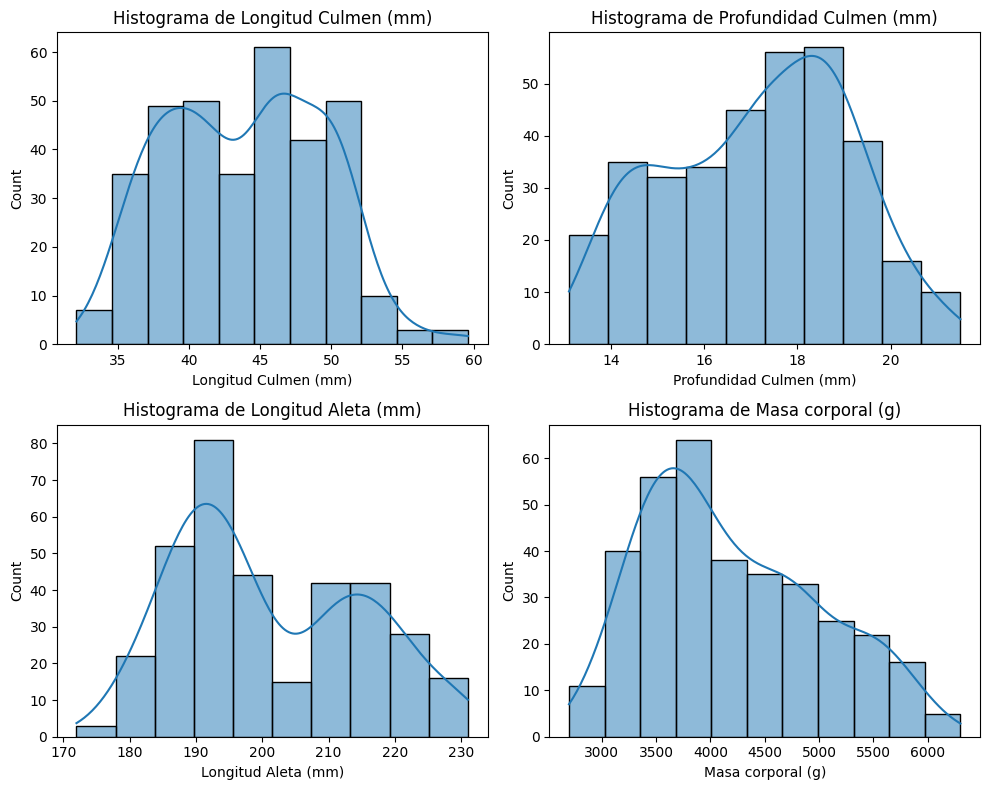

In [50]:
plt.figure(figsize=(10,8))

for i, col in enumerate(raw_num):
    plt.subplot(2, 2, i+1)
    sns.histplot(raw_num[col], kde=True)
    plt.title(f"Histograma de {col}")

plt.tight_layout()
plt.show()

Comentarios sobre los histogramas:

**Correcciones de variables cuantitativas**

In [11]:
raw_num[raw_num.isna().all(axis=1)]

,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g)
3,NaN,NaN,NaN,NaN
342,NaN,NaN,NaN,NaN


In [12]:
raw_data = raw_data.dropna(subset=raw_num.columns)

In [13]:
raw_data.info()

<class 'pandas.DataFrame'>
Index: 345 entries, 0 to 346
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Especie                  345 non-null    str    
 1   Longitud Culmen (mm)     345 non-null    float64
 2   Profundidad Culmen (mm)  345 non-null    float64
 3   Longitud Aleta (mm)      345 non-null    float64
 4   Masa corporal (g)        345 non-null    float64
 5   Sexo                     336 non-null    str    
dtypes: float64(4), str(2)
memory usage: 24.2 KB


La única variable con nulos es Sexo. Como es posible que sea una variable importante para este análisis, se procede con reemplazar los nulos a través de KNN.

**Imputación de nulos**

In [14]:
raw_data["Sexo"].value_counts(dropna=False)

Sexo
M      170
F      166
NaN      9
Name: count, dtype: int64

In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

In [16]:
col_num = ["Longitud Culmen (mm)", "Profundidad Culmen (mm)", "Longitud Aleta (mm)", "Masa corporal (g)"]

In [17]:
sex_conc = raw_data[raw_data["Sexo"].notna()]
sex_descon = raw_data[raw_data["Sexo"].isna()]

In [18]:
# Escalado para que todas las variables influyan sin ventaja
scaler = StandardScaler()
X_train = scaler.fit_transform(sex_conc[col_num])
X_pred  = scaler.transform(sex_descon[col_num])

In [19]:
# entrenar sobre las conocidas, predecir las 9 restantes
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, sex_conc["Sexo"])

raw_data.loc[raw_data["Sexo"].isna(), "Sexo"] = knn.predict(X_pred)

In [20]:
raw_data["Sexo"].value_counts(dropna=False)

Sexo
F    173
M    172
Name: count, dtype: int64

In [21]:
raw_data["Sexo"] = raw_data["Sexo"].map({"M": 0, "F": 1})

In [22]:
raw_data["Sexo"].value_counts(dropna=False)

Sexo
1    173
0    172
Name: count, dtype: int64

**Correlaciones**

In [23]:
data = raw_data.copy()

In [24]:
X = data.drop(columns='Especie')
y = data['Especie']

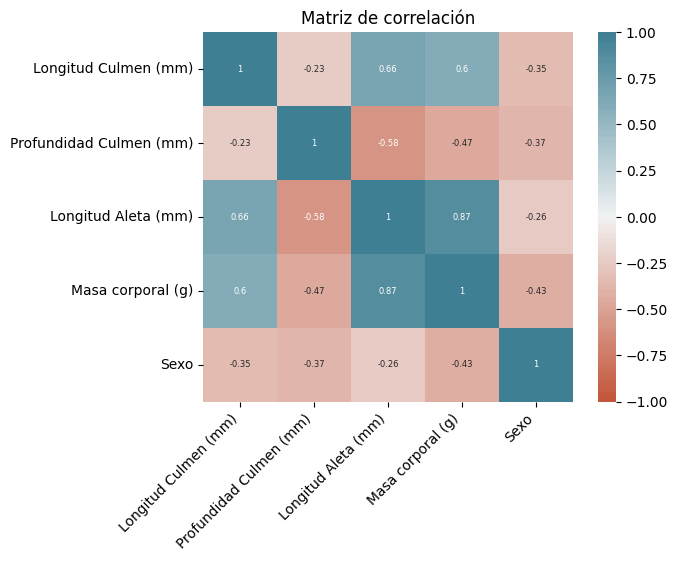

In [25]:
corr = X.corr()
ax = sns.heatmap(
    corr,
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True,
    annot = True,
    annot_kws = {'size': 6})

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    horizontalalignment='right')

plt.title('Matriz de correlación')
plt.show()

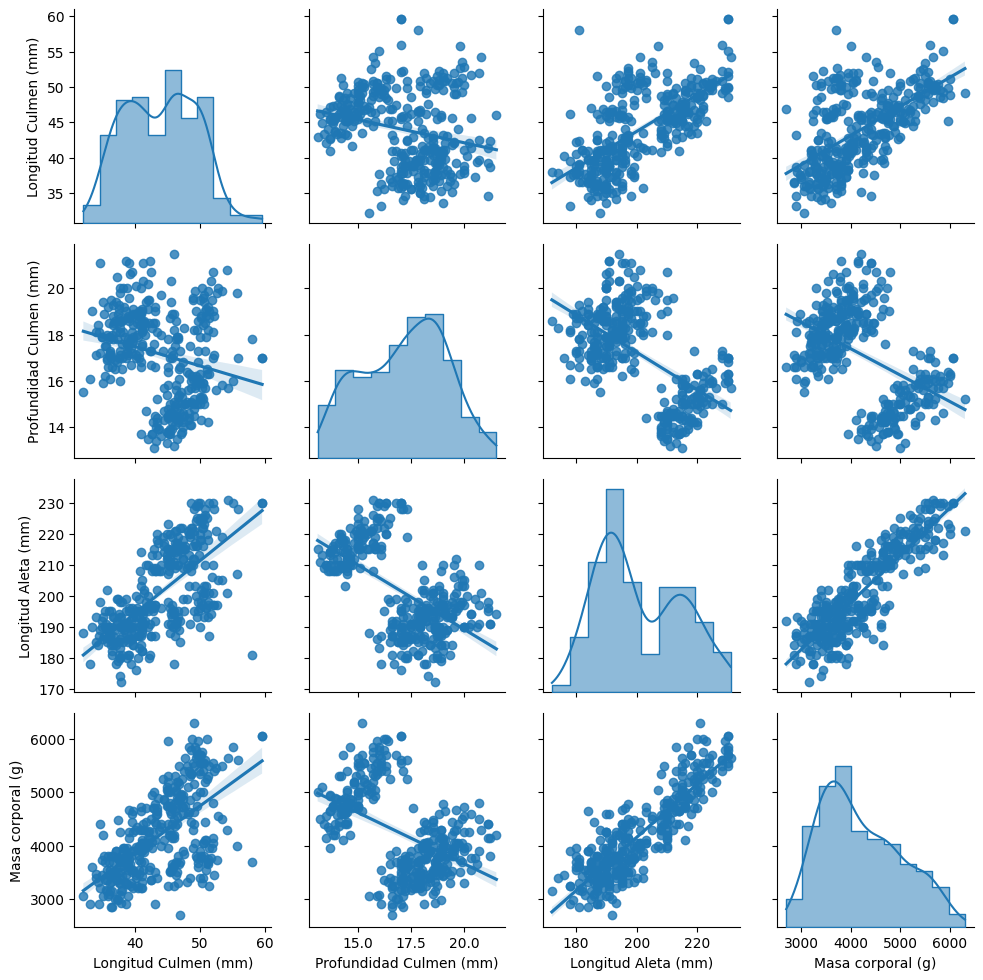

In [26]:
g = sns.PairGrid(X[col_num])
g.map_diag(sns.histplot, kde=True, element='step')
g.map_offdiag(sns.regplot)

Consideraciones:
- Multicolinealidad entre Masa Corporal y Longitud Aleta, visto tanto en la matriz como en gráfico de puntos; distribución muy apretada y pegada a la recta. Respuesta lógica ya que cuanta más longitud tenga un animal, más masa tendrá.
- Distribuciones bimodales en Longitud Aleta y Longitud Culmen. Pude deberse a que dos grupos sobresalen más que otros.
- Dos nubes de puntos entre Longitud Aleta y Profundidad Culmen y Masa y Profundidad Culmen. Se marcan dos subgrupos potenciales.

**Búsqueda de valores atípicos**

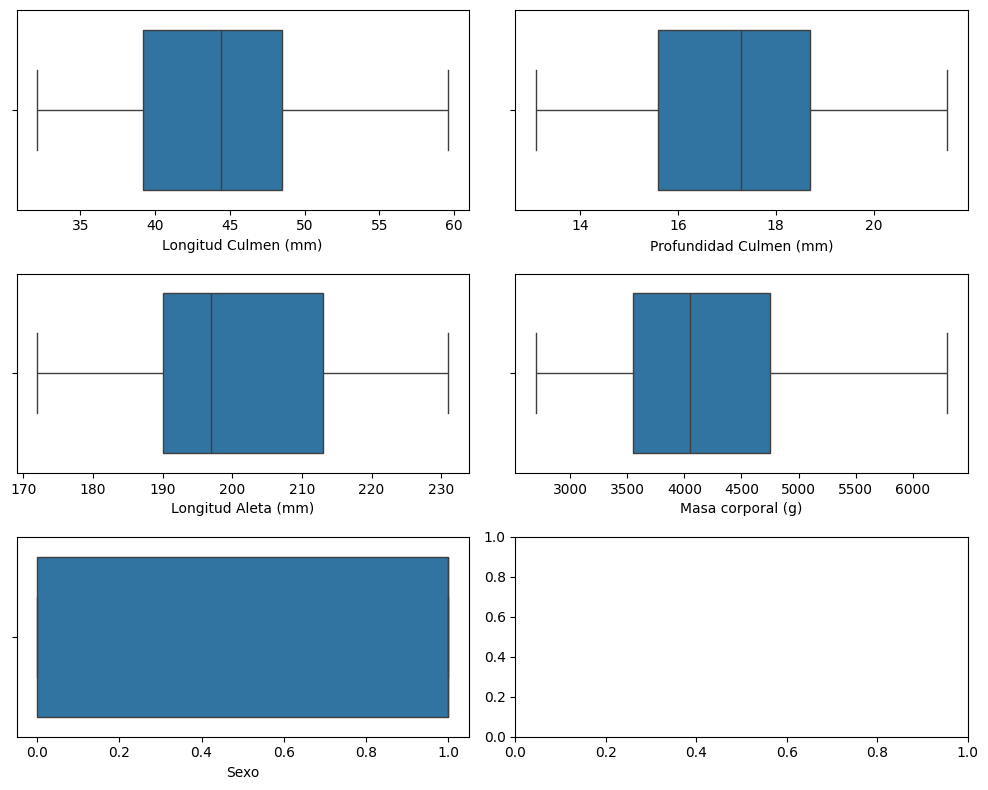

In [27]:
cols = X.columns
fig, axes = plt.subplots(nrows=3, ncols=2, sharey=False, figsize=(10, 8))
for i, col in enumerate(cols, 1):
    sns.boxplot(data=X, x=col, ax=axes.flatten()[i-1])
plt.tight_layout()
plt.show()

No hay outliers en ninguna de las variables.

#### PCA

In [28]:
# Flujo de datos
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

# Reducción de dimensionalidad
from sklearn.decomposition import PCA
from sklearn.manifold import MDS, Isomap, TSNE

In [29]:
pca_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA().set_output(transform="pandas"))
])

df_pca = pca_pipeline.fit_transform(data[col_num]) # var sin var. obj.
df_pca.shape[1]

4

In [30]:
df_pca.head()

,pca0,pca1,pca2,pca3
0,-1.840277,0.061303,-0.230030,-0.522973
1,-1.305628,-0.421944,-0.032015,-0.402291
2,-1.367299,-0.150060,0.196627,0.524761
3,-1.875249,0.020357,-0.614867,0.475637
4,-1.908107,0.851853,-0.675465,0.206848


Varianza acumulada

In [31]:
# Varianza explicada y acumulada
var_exp = pca_pipeline.named_steps['pca'].explained_variance_ratio_
var_cum = np.cumsum(var_exp) #linea roja posterior
n_comp = len(var_exp) #para ejes del grafico

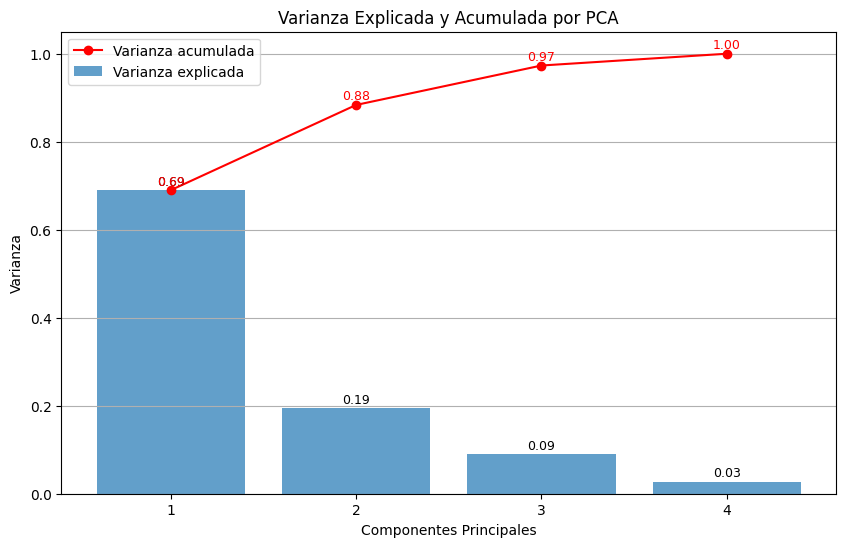

In [32]:
fig, ax = plt.subplots(figsize=(10,6))
bars = ax.bar(range(1, n_comp+1), var_exp, alpha=0.7, label='Varianza explicada')

# Línea: varianza acumulada
line = ax.plot(range(1, n_comp+1), var_cum, color='red', marker='o', label='Varianza acumulada')

# Etiquetas sobre las barras
for bar, v in zip(bars, var_exp):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.005, f"{v:.2f}", ha='center', va='bottom', fontsize=9)

# Etiquetas sobre los puntos de la línea
for i, v in enumerate(var_cum, start=1):
    ax.text(i, v + 0.005, f"{v:.2f}", color='red', ha='center', va='bottom', fontsize=9)

# Etiquetas y estilo
ax.set_xlabel('Componentes Principales')
ax.set_ylabel('Varianza')
ax.set_title('Varianza Explicada y Acumulada por PCA')
ax.set_xticks(range(1, n_comp+1))
ax.legend()
ax.grid(axis='y')

plt.show()

Consideraciones:
Un componente logra casi el 70% de la varianza explicada. Sin embargo, se llega a 88% muy apreciables con dos componentes. Agregar un tercero no implica un incremento muy destacable (de 88 a 97%).

Criterio de Kaisser

In [33]:
autovalores = pca_pipeline.named_steps['pca'].explained_variance_
autovalores  # Por el criterio de Kaisser, solo hay que destaca 1 componente.

array([2.76720861, 0.77730861, 0.35962263, 0.10748805])

Criterio del Codo

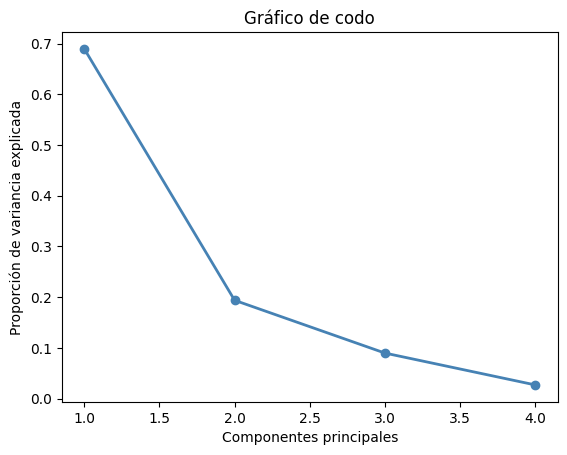

In [34]:
PC_values = np.arange(pca_pipeline.named_steps['pca'].n_components_) + 1
plt.plot(PC_values, pca_pipeline.named_steps['pca'].explained_variance_ratio_, 'o-', linewidth=2, color='steelblue')
plt.title('Gráfico de codo')
plt.xlabel('Componentes principales')
plt.ylabel('Proporción de variancia explicada')
plt.show()

Tras la observación de los tres criterios dados (Varianza acumulada, Criterio de Kaisser y Criterio del Codo), se puede llegar a la conclusión de que quedarse con solo dos componentes implica quedarse con 88% de los datos, lo cual no es nada despreciable.

**Visualizaciones:**

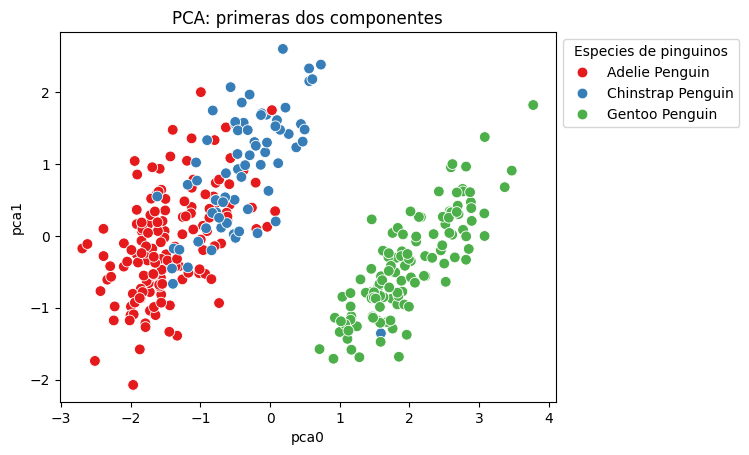

In [35]:
#scatterplot las primeras dos componentes
sns.scatterplot(
    x=df_pca['pca0'],
    y=df_pca['pca1'], # dos componentes
    hue=data['Especie'],
    palette='Set1',
    s=60)

plt.xlabel('pca0')
plt.ylabel('pca1')
plt.title('PCA: primeras dos componentes')
plt.legend(title='Especies de pinguinos', bbox_to_anchor=(1, 1), loc='upper left')
plt.show()

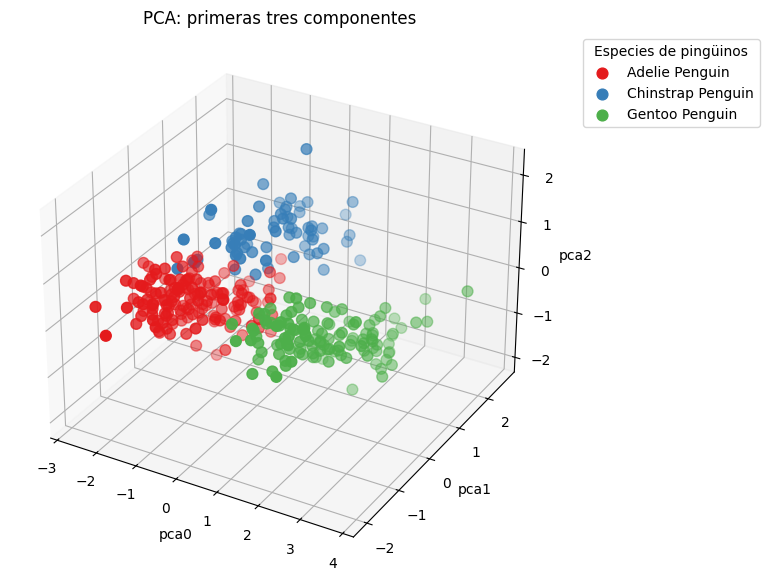

In [36]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(projection='3d')

especies = data['Especie'].unique()
colores = sns.color_palette('Set1', len(especies))

for especie, color in zip(especies, colores):
    mask = (data['Especie'] == especie).to_numpy()
    ax.scatter(
        df_pca['pca0'].to_numpy()[mask],
        df_pca['pca1'].to_numpy()[mask],
        df_pca['pca2'].to_numpy()[mask], # tres componentes
        color=color,
        s=60,
        label=especie)

ax.set_xlabel('pca0')
ax.set_ylabel('pca1')
ax.set_zlabel('pca2')
ax.set_title('PCA: primeras tres componentes')
ax.legend(title='Especies de pingüinos', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

**Cierre elección de componentes:**

Las visualizaciones permiten ver que el porcentaje aportado por el tercer componente ayuda a visualizar mejor a los tres grupos de animales estudiados, a pesar de ser solo 9%. Esto más una reevaluación del criterio de varianza acumulada, prioriza la elección de tres componentes.

#### ISOMAP

In [37]:
scaler = StandardScaler()
X_std = scaler.fit_transform(data[col_num])
y = data['Especie']

In [38]:
isomap_2D = Isomap(n_neighbors=12, n_components=2).set_output(transform="pandas")
X_2D = isomap_2D.fit_transform(X_std)

c:\Users\Carolina\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\manifold\_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
c:\Users\Carolina\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\scipy\sparse\_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


In [39]:
X_2D.shape

(345, 2)

In [40]:
isomap_2D_3cmp = Isomap(n_neighbors=20, n_components=3).set_output(transform="pandas")
X_2D_3cmp = isomap_2D_3cmp.fit_transform(X_std)

c:\Users\Carolina\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\manifold\_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
c:\Users\Carolina\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\scipy\sparse\_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


In [41]:
X_2D_3cmp.shape

(345, 3)

Visualizaciones ISOMAP

In [42]:
categorias = y.unique()
colores = sns.color_palette('Set1', n_colors=len(categorias))
colors = colores.as_hex()

In [43]:
nombres_col = X_2D.columns
fig_isomap2d = px.scatter(X_2D, x=nombres_col[0], y=nombres_col[1],
                           color = data['Especie'],
                           labels = {'color':'Especie',
                                     'C1':nombres_col[0],'C2':nombres_col[1]},
                           color_discrete_sequence=colors,
                           hover_name=data['Especie'].to_numpy(),
                           title='ISOMAP 2D')
fig_isomap2d.show()

Observaciones:

- ISOMAP visualiza mejor a los grupos Adelie y Chinstrap, con más claridad espacial que PCA, logrando en 2D una distinción que en PCA requería la 3° componente.
- La especie Gentoo fue "desenrollada" por ISOMAP, reflejando su variación interna sobre el manifold.

#### t-SNE

In [44]:
tsne2D = TSNE(n_components=2, perplexity=15, init='random', random_state=42,
              method='exact').set_output(transform="pandas")
X_tsne2D = tsne2D.fit_transform(X_std)

In [45]:
print(X_tsne2D.shape)

(345, 2)


Visualización de t-SNE

In [46]:
col_names = X_tsne2D.columns
fig_tsne2d = px.scatter(X_tsne2D, x=col_names[0], y=col_names[1],
                           color = data['Especie'],
                            labels = {'color':'Especie', 'C1':nombres_col[0],'C2':nombres_col[1]},
                            color_discrete_sequence=colors,
                            hover_name=data['Especie'].to_numpy(),
                           title='t-SNE 2D')
fig_tsne2d.show()

Observaciones:
- La mejor visualización en cuento a la separación de grupos, incluso en el par Adelie-Chinstrap, con mínimo solapamiento.
- Las distancias entre grupos no es relevante ya que t-SNE da peso a la estrutura local.
- Con perplejidad=5, los grupos se ven más desintegrados.